# Student Performance - Machine Learning Workflow

## 1. Initial Data Loading
We start by loading the dataset to see what we are working with. We will check the shape and the data types of our columns to ensure everything is loaded correctly.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv('Day18_19_student_habits_performance.csv')

display(df.head())
display(df.info())

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str    
 13  

None

## 2. Exploratory Data Analysis (EDA)
We need to find out if there are missing values and see how our target variable, the exam score, is distributed. We also look at how different habits correlate with the score to spot obvious trends before feeding data to the model.

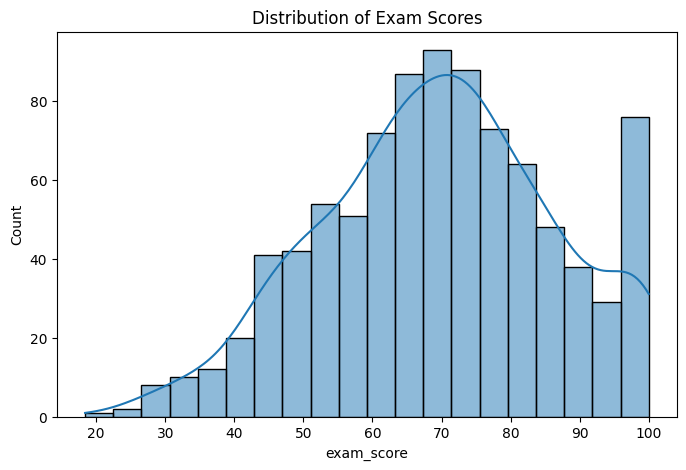

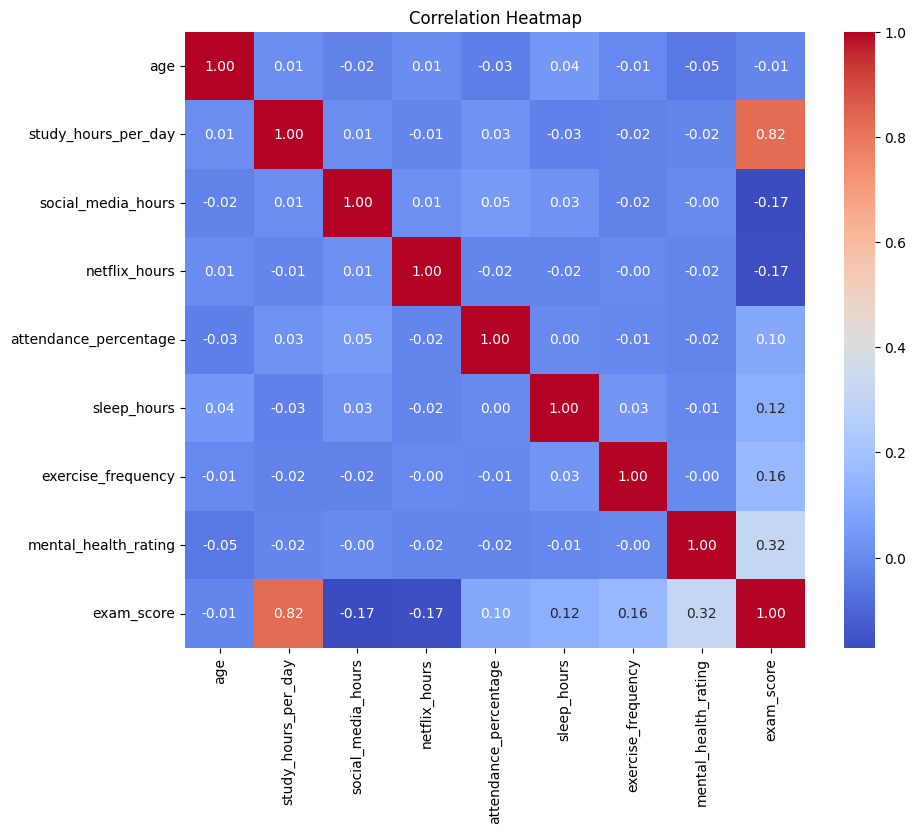

In [12]:
df = df.dropna()

df.columns = df.columns.astype(str)

plt.figure(figsize=(8, 5))
sns.histplot(df['exam_score'], bins=20, kde=True)
plt.title('Distribution of Exam Scores')
plt.show()

numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 3. Data Preparation and Regression Model
We prepare our features and scale them so the math works smoothly. Then we split the data 80/20 and train a Linear Regression model to predict the exact exam score.

In [13]:
X = df[['study_hours_per_day', 'attendance_percentage', 'sleep_hours', 'social_media_hours', 'netflix_hours', 'mental_health_rating']]

if 'exercise_frequency' in df.columns:
    X = X.join(pd.get_dummies(df['exercise_frequency'], drop_first=True))

X.columns = X.columns.astype(str)

y_reg = df['exam_score']

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train_reg)

y_pred_train_reg = reg_model.predict(X_train_scaled)
y_pred_test_reg = reg_model.predict(X_test_scaled)

print("Regression Train R2:", r2_score(y_train_reg, y_pred_train_reg))
print("Regression Test R2:", r2_score(y_test_reg, y_pred_test_reg))
print("Regression Test RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_test_reg)))

Regression Train R2: 0.902083463105179
Regression Test R2: 0.8899069599420486
Regression Test RMSE: 5.466524376173154


## 4. Classification Model
Now we turn this into a classification problem. Anyone scoring 50 or above passes, and below 50 fails. We train a Logistic Regression model to predict this Pass/Fail status based on the exact same scaled features.

In [14]:
y_class = (df['exam_score'] >= 50).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)

X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

clf_model = LogisticRegression()
clf_model.fit(X_train_c_scaled, y_train_c)

y_pred_train_c = clf_model.predict(X_train_c_scaled)
y_pred_test_c = clf_model.predict(X_test_c_scaled)

print("Classification Train Accuracy:", accuracy_score(y_train_c, y_pred_train_c))
print("Classification Test Accuracy:", accuracy_score(y_test_c, y_pred_test_c))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_c, y_pred_test_c))
print("Precision:", precision_score(y_test_c, y_pred_test_c, zero_division=0))
print("Recall:", recall_score(y_test_c, y_pred_test_c, zero_division=0))
print("F1 Score:", f1_score(y_test_c, y_pred_test_c, zero_division=0))

Classification Train Accuracy: 0.9573590096286108
Classification Test Accuracy: 0.967032967032967

Confusion Matrix:
 [[ 13   4]
 [  2 163]]
Precision: 0.9760479041916168
Recall: 0.9878787878787879
F1 Score: 0.9819277108433735


## 5. Model Evaluation & Overfitting Check
By comparing the training scores to the testing scores, we can check for overfitting. If the training score is massive but the testing score drops significantly, the model memorized the data instead of learning it. When both metrics align closely, it means the model is generalizing well.

## 6. Key Insights
Study Time Drives Success: At a 0.82 correlation, daily study hours are the absolute strongest predictor of high exam scores.

Well-being Matters: Mental health (0.32), exercise (0.16), and sleep (0.12) consistently improve academic performance.

Screen Time Harms Scores: Both Netflix and social media hours show a clear negative correlation (-0.17) with final grades.

Solid Score Predictions: The regression model reliably predicts exact scores within a 5.5-mark margin without overfitting (Train R2: 0.90, Test R2: 0.89).

Highly Accurate Classification: The Pass/Fail model correctly categorized 96.7% of test cases, missing only 6 out of 182.